In [1]:
import jax
import flax
import optax
from jax import lax, random, value_and_grad, numpy as jnp
from jax import random, grad, vmap, hessian, jacfwd, jit
from jax import config
from jax.tree_util import Partial, tree_map
from flax import linen as nn
import jax_dataloader as jd

import time
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import colors

import torch
from torch.utils.data import Dataset

import os
import h5py
from tqdm.auto import tqdm

#os.environ['CUDA_VISIBLE_DEVICES'] = '1'
config.update("jax_enable_x64", True)
os.environ['XLA_PYTHON_CLIENT_ALLOCATOR'] = 'cuda_async'
os.environ['XLA_PYTHON_CLIENT_PREALLOCATE'] = 'true' # default is true, 90% of GPU VRAM preallocated

In [2]:
beta = 10.0

DATA_DIR = Path.cwd().parent.parent / "data" / "darcy_flow_data" 
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train.hdf5"

scale_factor = 1
NEW_FILE_PATH = DATA_DIR / f"2D_DarcyFlow_beta10.0_Train_Scale{scale_factor}.hdf5"

--- Numerical Sanity Checks (Sample 1) ---
Contains NaNs: False
Max absolute value on u boundaries: 3.635139e-01 (Should be ~0.0)


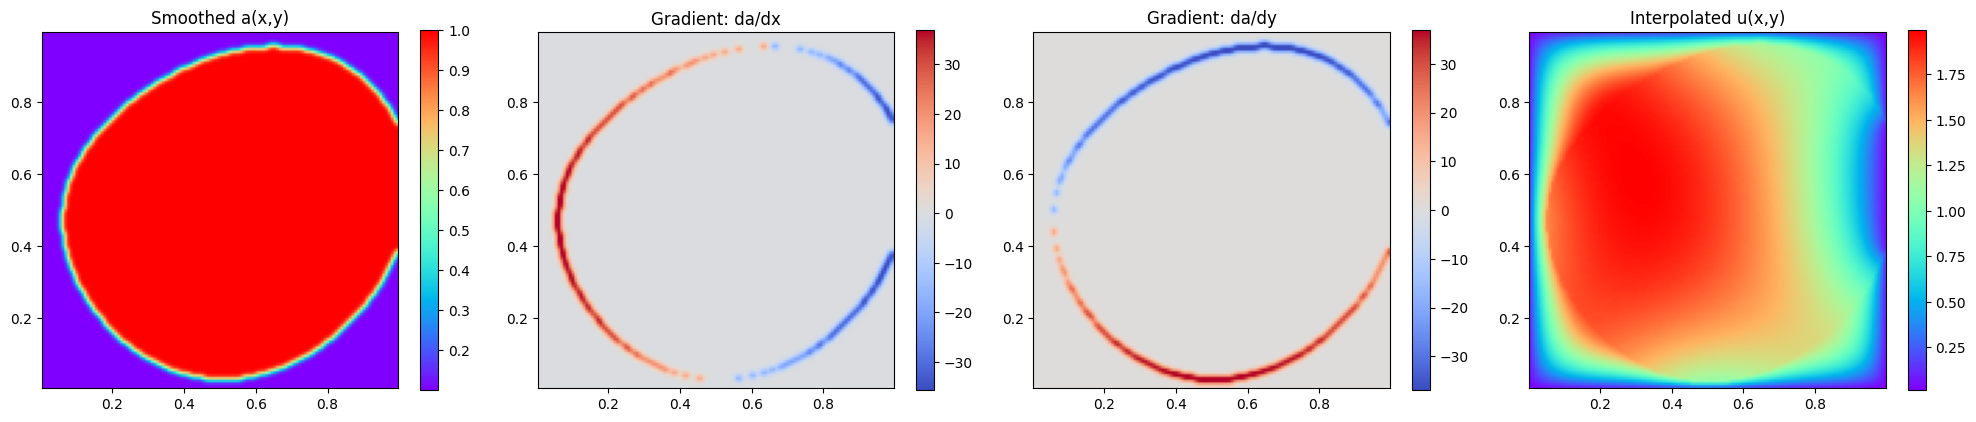

In [3]:
# Adjust path and scale_factor if needed
FILE_PATH = DATA_DIR / "2D_DarcyFlow_beta10.0_Train_Scale1.hdf5"

sample_idx = 1

with h5py.File(FILE_PATH, 'r') as f:
    fine_x = f['x-coordinate'][:]
    fine_y = f['y-coordinate'][:]
    fine_nx, fine_ny = len(fine_x), len(fine_y)
    
    a_2d = f['a_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ax_2d = f['a_x_flat'][sample_idx].reshape(fine_nx, fine_ny)
    ay_2d = f['a_y_flat'][sample_idx].reshape(fine_nx, fine_ny)
    u_2d = f['u_flat'][sample_idx].reshape(fine_nx, fine_ny)

# --- Numerical Checks ---
print(f"--- Numerical Sanity Checks (Sample {sample_idx}) ---")
print(f"Contains NaNs: {np.isnan(a_2d).any() or np.isnan(u_2d).any()}")

# Extract the boundary pixels of u
u_boundaries = np.concatenate([
    u_2d[0, :], u_2d[-1, :],  # Left and Right edges
    u_2d[:, 0], u_2d[:, -1]   # Bottom and Top edges
])
max_boundary_val = np.max(np.abs(u_boundaries))
print(f"Max absolute value on u boundaries: {max_boundary_val:.6e} (Should be ~0.0)")

# --- Visual Checks ---
# We transpose (.T) to match Cartesian plotting (x on horizontal, y on vertical)
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
ext = [fine_x.min(), fine_x.max(), fine_y.min(), fine_y.max()]

im0 = axes[0].imshow(a_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[0].set_title("Smoothed a(x,y)")
fig.colorbar(im0, ax=axes[0])

im1 = axes[1].imshow(ax_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[1].set_title("Gradient: da/dx")
fig.colorbar(im1, ax=axes[1])

im2 = axes[2].imshow(ay_2d.T, origin='lower', cmap='coolwarm', extent=ext)
axes[2].set_title("Gradient: da/dy")
fig.colorbar(im2, ax=axes[2])

im3 = axes[3].imshow(u_2d.T, origin='lower', cmap='rainbow', extent=ext)
axes[3].set_title("Interpolated u(x,y)")
fig.colorbar(im3, ax=axes[3])

plt.tight_layout()
plt.show()

In [4]:
print(f"Loading pre-processed dataset: {NEW_FILE_PATH.name}")

with h5py.File(NEW_FILE_PATH, 'r') as f:
    fine_x_coords = np.array(f['x-coordinate'][:])
    fine_y_coords = np.array(f['y-coordinate'][:])
    
    # Load the pre-calculated, pre-flattened arrays into memory
    all_a_flat = np.array(f['a_flat'][:])
    all_a_x_flat = np.array(f['a_x_flat'][:])
    all_a_y_flat = np.array(f['a_y_flat'][:])
    all_u_flat = np.array(f['u_flat'][:])

N_samples = all_a_flat.shape[0]
fine_nx, fine_ny = len(fine_x_coords), len(fine_y_coords)

# Coordinate generation
# Coordinate generation
x_l, x_u = float(np.min(fine_x_coords)), float(np.max(fine_x_coords)) 
y_l, y_u = float(np.min(fine_y_coords)), float(np.max(fine_y_coords)) 

X, Y = np.meshgrid(fine_x_coords, fine_y_coords, indexing='ij')
x = jnp.array(X.reshape(-1, 1))
y = jnp.array(Y.reshape(-1, 1))

# Because the HDF5 grid is cell-centered, ALL of these are strictly valid interior points
x_valid = x
y_valid = y
total_valid_points = x_valid.shape[0]

# --- Generate True Mathematical Boundaries ---
# The domain is defined mathematically as the unit square (0,1)^2
# Dynamically scale the boundary density to match the interior grid
edge_x = jnp.linspace(0.0, 1.0, fine_nx)
edge_y = jnp.linspace(0.0, 1.0, fine_ny)

# Bottom (y=0.0) and Top (y=1.0)
bc_bottom = jnp.stack([edge_x, jnp.zeros_like(edge_x)], axis=-1)
bc_top = jnp.stack([edge_x, jnp.ones_like(edge_x)], axis=-1)

# Left (x=0.0) and Right (x=1.0)
bc_left = jnp.stack([jnp.zeros_like(edge_y), edge_y], axis=-1)
bc_right = jnp.stack([jnp.ones_like(edge_y), edge_y], axis=-1)

# Combine all true boundary coordinates
all_bc_coords = jnp.concatenate([bc_bottom, bc_top, bc_left, bc_right], axis=0)
x_bc = all_bc_coords[:, 0].reshape(-1, 1)
y_bc = all_bc_coords[:, 1].reshape(-1, 1)

# Enforce exactly u=0.0 on these true boundaries
bc_val_array = jnp.zeros_like(x_bc)

Loading pre-processed dataset: 2D_DarcyFlow_beta10.0_Train_Scale1.hdf5


E0729 05:45:47.051012    3496 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)
E0729 05:45:47.123046    3360 cuda_executor.cc:1526] Could not get kernel mode driver version: (INVALID_ARGUMENT: Version does not match the format X.Y.Z)


In [5]:
class DarcyFlowDataset(Dataset):
    def __init__(self, a_data, a_x_data, a_y_data, u_data):
        self.a = a_data
        self.a_x = a_x_data
        self.a_y = a_y_data
        self.u = u_data

    def __len__(self): return len(self.a)
    def __getitem__(self, idx): return self.a[idx], self.a_x[idx], self.a_y[idx], self.u[idx]

# n_train = int(N_samples * 0.9)
# n_val = int(N_samples * 0.05)

# train_dataset = DarcyFlowDataset(all_a_flat[:n_train], all_a_x_flat[:n_train], all_a_y_flat[:n_train], all_u_flat[:n_train])
# val_dataset = DarcyFlowDataset(all_a_flat[n_train:n_train+n_val], all_a_x_flat[n_train:n_train+n_val], all_a_y_flat[n_train:n_train+n_val], all_u_flat[n_train:n_train+n_val])
# test_dataset = DarcyFlowDataset(all_a_flat[n_train+n_val:], all_a_x_flat[n_train+n_val:], all_a_y_flat[n_train+n_val:], all_u_flat[n_train+n_val:])

# batch_size_samples = 8 
# train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
# val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False)
# test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=False)

n_train = 4
n_val = 5
n_test = 5
N_subset = n_train + n_val + n_test

# Slice sequentially to completely isolate the sets
train_dataset = DarcyFlowDataset(
    all_a_flat[:n_train], 
    all_a_x_flat[:n_train], 
    all_a_y_flat[:n_train], 
    all_u_flat[:n_train]
)

val_dataset = DarcyFlowDataset(
    all_a_flat[n_train : n_train + n_val], 
    all_a_x_flat[n_train : n_train + n_val], 
    all_a_y_flat[n_train : n_train + n_val], 
    all_u_flat[n_train : n_train + n_val]
)

test_dataset = DarcyFlowDataset(
    all_a_flat[n_train + n_val : N_subset], 
    all_a_x_flat[n_train + n_val : N_subset], 
    all_a_y_flat[n_train + n_val : N_subset], 
    all_u_flat[n_train + n_val : N_subset]
)

# Batch sizes
batch_size_samples = 4
train_dataloader = jd.DataLoader(train_dataset, backend='pytorch', batch_size=batch_size_samples, shuffle=True, drop_last=True)
val_dataloader = jd.DataLoader(val_dataset, backend='pytorch', batch_size=n_val, shuffle=False)
test_dataloader = jd.DataLoader(test_dataset, backend='pytorch', batch_size=n_test, shuffle=False)

print(f"DataLoaders ready! (Train: {n_train}, Val: {n_val}, Test: {n_test})")

DataLoaders ready! (Train: 4, Val: 5, Test: 5)


In [6]:
epochs = 1000
M = 512
chunk_size = 256 
hidden_layers = [512,512,512,512] 

total_features = hidden_layers[-1]
# sum(hidden_layers)

sigma = 1
tik_reg_fixed = 1e-6
matrix_bc_weight = 1e2
pde_loss_weight = 1.0
bc_loss_weight = 1e2
data_loss_weight = 0

rff_key = jax.random.PRNGKey(99)
B_matrix = jax.random.normal(rff_key, (2, M)) * sigma

# class FeatureExtractor(nn.Module):
#     hidden_layers: list
#     B_matrix: jnp.ndarray 
    
#     @nn.compact
#     def __call__(self, x_in, y_in):    

#         v = jnp.concatenate([x_in, y_in])

#         proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
#         h_rff = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])
#         all_features = []

#         h = h_rff
#         for size in self.hidden_layers:
#             h = nn.Dense(size, kernel_init=nn.initializers.he_normal())(h)
#             h = nn.tanh(h) 
#             all_features.append(h)
            
#         # Combine RFF and all MLP layers
#         combined_h = jnp.concatenate(all_features)
            
#         return combined_h

class FeatureExtractor(nn.Module):
    hidden_layers: list
    B_matrix: jnp.ndarray 
    
    @nn.compact
    def __call__(self, x_in, y_in):    
        v = jnp.concatenate([x_in, y_in])
        proj = 2.0 * jnp.pi * jnp.dot(v, self.B_matrix)
        h = jnp.concatenate([jnp.sin(proj), jnp.cos(proj)])

        for size in self.hidden_layers:
            h = nn.Dense(size, kernel_init=nn.initializers.glorot_normal())(h)
            h = nn.tanh(h) 
        return h 
    
model = FeatureExtractor(
    hidden_layers=hidden_layers, 
    B_matrix=B_matrix 
)

key = jax.random.PRNGKey(0)
dummy_x = jnp.array([0.0])
dummy_y = jnp.array([0.0])
params = model.init(key, dummy_x, dummy_y)

print(f"Calculated Total Features for V1: {total_features}")

Calculated Total Features for V1: 512


In [7]:
def get_f(params, x_val, y_val):
    return model.apply(params, x_val, y_val)

def get_f_dir(params, x_val, y_val):
    f_x = jacfwd(get_f, argnums=1)(params, x_val, y_val)
    f_y = jacfwd(get_f, argnums=2)(params, x_val, y_val)
    f_xx = jacfwd(jacfwd(get_f, argnums=1), argnums=1)(params, x_val, y_val)
    f_yy = jacfwd(jacfwd(get_f, argnums=2), argnums=2)(params, x_val, y_val)
    
    f_x = jnp.squeeze(f_x, axis=-1)
    f_y = jnp.squeeze(f_y, axis=-1)
    f_xx = jnp.squeeze(f_xx, axis=(-1, -2))
    f_yy = jnp.squeeze(f_yy, axis=(-1, -2))
    return f_x, f_y, f_xx, f_yy

def get_f_chunk(params, x_val, y_val, start_idx, end_idx):
    f = model.apply(params, x_val, y_val)
    return lax.dynamic_slice(f, (start_idx,), (end_idx - start_idx,))

def get_f_dir_chunk(params, x_val, y_val, start_idx, end_idx):
    f_x_chunk = jacfwd(get_f_chunk, argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_y_chunk = jacfwd(get_f_chunk, argnums=2)(params, x_val, y_val, start_idx, end_idx)
    f_xx_chunk = jacfwd(jacfwd(get_f_chunk, argnums=1), argnums=1)(params, x_val, y_val, start_idx, end_idx)
    f_yy_chunk = jacfwd(jacfwd(get_f_chunk, argnums=2), argnums=2)(params, x_val, y_val, start_idx, end_idx)
    
    f_x_chunk = jnp.squeeze(f_x_chunk, axis=-1)
    f_y_chunk = jnp.squeeze(f_y_chunk, axis=-1)
    f_xx_chunk = jnp.squeeze(f_xx_chunk, axis=(-1, -2))
    f_yy_chunk = jnp.squeeze(f_yy_chunk, axis=(-1, -2))
    return f_x_chunk, f_y_chunk, f_xx_chunk, f_yy_chunk

def get_u_dir(params, x_val, y_val, w_current):
    f_x, f_y, f_xx, f_yy = get_f_dir(params, x_val, y_val)
    u_x = jnp.dot(f_x, w_current)
    u_y = jnp.dot(f_y, w_current)
    u_xx = jnp.dot(f_xx, w_current)
    u_yy = jnp.dot(f_yy, w_current)
    return u_x, u_y, u_xx, u_yy

f_spatial_vmap = vmap(get_f, in_axes=(None, 0, 0))
f_dir_spatial_vmap = vmap(get_f_dir, in_axes=(None, 0, 0))
f_chunk_spatial_vmap = vmap(get_f_chunk, in_axes=(None, 0, 0, None, None))
f_dir_chunk_spatial_vmap = vmap(get_f_dir_chunk, in_axes=(None, 0, 0, None, None))
u_dir_spatial_vmap = vmap(get_u_dir, in_axes=(None, 0, 0, None))

In [8]:
total_steps = epochs * len(train_dataloader)
lr_schedule = optax.cosine_decay_schedule(init_value=1e-3, decay_steps=total_steps, alpha=0.01)
optimizer = optax.adamw(learning_rate=lr_schedule, weight_decay=1e-4)

# The vmap now ONLY handles the lightweight array multiplication
def multiply_coefficients(f_x, f_y, f_xx, f_yy, a_pde, a_x_pde, a_y_pde):
    return -(a_x_pde * f_x + a_y_pde * f_y + a_pde * (f_xx + f_yy))

batched_multiply = jax.vmap(multiply_coefficients, in_axes=(None, None, None, None, 0, 0, 0))

def get_A_and_b_optimized(params, x_pde, y_pde, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_chunks = []
    
    # Compute Boundary Features (Runs ONCE)
    A_bc_full = []
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        A_bc_chunk = f_chunk_spatial_vmap(params, x_bc, y_bc, start_idx, end_idx) * jnp.sqrt(matrix_bc_weight)
        A_bc_full.append(A_bc_chunk)
    A_bc_matrix = jnp.hstack(A_bc_full)
    
    # Iterate through chunks to assemble the full PDE matrix
    for start_idx in range(0, total_features, chunk_size):
        end_idx = min(start_idx + chunk_size, total_features)
        
        # Runs ONCE per spatial chunk, regardless of batch size
        f_x, f_y, f_xx, f_yy = f_dir_chunk_spatial_vmap(params, x_pde, y_pde, start_idx, end_idx)
        
        # Broadcasts the scalar/array multiplication across the batch
        A_pde_batch = batched_multiply(f_x, f_y, f_xx, f_yy, a_batch, a_x_batch, a_y_batch)
        
        # Slice the pre-computed boundary matrix to match the current chunk's width
        A_bc_chunk_sliced = A_bc_matrix[:, start_idx:end_idx]
        
        # Stack PDE and BC for every sample in the batch
        A_bc_batched = jnp.repeat(A_bc_chunk_sliced[None, ...], a_batch.shape[0], axis=0)
        A_chunk_batched = jnp.concatenate([A_pde_batch, A_bc_batched], axis=1)
        
        A_chunks.append(A_chunk_batched)
        
    A_full_batch = jnp.concatenate(A_chunks, axis=-1)
    
    # Assemble target vector b
    b_pde = jnp.ones_like(a_batch) * beta
    b_bc = bc_val_arr * jnp.sqrt(matrix_bc_weight)
    b_bc_batched = jnp.repeat(b_bc[None, ...], a_batch.shape[0], axis=0)
    b_full_batch = jnp.concatenate([b_pde, b_bc_batched], axis=1)
    
    return A_full_batch, b_full_batch

@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size):
    A_batch, b_batch = get_A_and_b_optimized(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    def solve_single(A, b):
        AtA = A.T @ A + tik_reg_fixed * jnp.eye(total_features)
        Atb = A.T @ b
        return jax.scipy.linalg.solve(AtA, Atb)
    
    return jax.vmap(solve_single)(A_batch, b_batch)

def compute_loss_single(params, w_current, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch):
    u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x_batch, y_batch, w_current)
    laplacian_u = u_xx + u_yy
    
    pde_residual = -(a_x_batch * u_x + a_y_batch * u_y + a_batch * laplacian_u) - beta
    
    f_bc_vals = f_spatial_vmap(params, x_bc, y_bc)
    u_bc_pred = jnp.dot(f_bc_vals, w_current)
    
    f_interior = f_spatial_vmap(params, x_batch, y_batch)
    u_pred_interior = jnp.dot(f_interior, w_current)
    
    loss_pde_unscaled = jnp.mean(pde_residual ** 2)
    loss_bc_unscaled = jnp.mean((u_bc_pred - bc_val_arr) ** 2)
    loss_data_unscaled = jnp.mean((u_pred_interior - u_batch) ** 2)
    
    loss_pde_scaled = loss_pde_unscaled * pde_loss_weight
    loss_bc_scaled = loss_bc_unscaled * bc_loss_weight
    loss_data_scaled = loss_data_unscaled * data_loss_weight
    
    return (loss_pde_scaled, loss_bc_scaled, loss_data_scaled), (loss_pde_unscaled, loss_bc_unscaled, loss_data_unscaled)

batched_compute_loss = jax.vmap(compute_loss_single, in_axes=(None, 0, None, None, 0, 0, 0, None, None, None, 0))

def compute_pde_bc_losses(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    w_batch = update_direct_solve_batch(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, total_features, chunk_size)
    
    scaled_tup, unscaled_tup = batched_compute_loss(params, w_batch, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch)
    
    l_pde_scaled = jnp.mean(scaled_tup[0])
    l_bc_scaled = jnp.mean(scaled_tup[1])
    l_data_scaled = jnp.mean(scaled_tup[2])
    
    # Stack ONLY PDE and BC scaled losses for the Jacobian computation
    loss_components = jnp.stack([l_pde_scaled, l_bc_scaled])
    
    # Pass the primal values out through the auxiliary return so we don't have to recompute them
    primals_scaled = (l_pde_scaled, l_bc_scaled, l_data_scaled)
    aux_unscaled = (jnp.mean(unscaled_tup[0]), jnp.mean(unscaled_tup[1]), jnp.mean(unscaled_tup[2]))
    
    return loss_components, (primals_scaled, aux_unscaled)

loss_jac_fn = jax.jit(jax.jacrev(compute_pde_bc_losses, argnums=0, has_aux=True), static_argnames=['total_features', 'chunk_size'])


@jax.jit(static_argnames=['total_features', 'chunk_size'])
def update_network(params, opt_state, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size):
    jac_grads, (primals_scaled, aux_unscaled) = loss_jac_fn(params, x_batch, y_batch, a_batch, a_x_batch, a_y_batch, x_bc, y_bc, bc_val_arr, u_batch, total_features, chunk_size)
    
    # Slice the PyTree using the updated tree_map import
    pde_grads = tree_map(lambda x: x[0], jac_grads)
    bc_grads = tree_map(lambda x: x[1], jac_grads)
    
    # Sum across axis 0 to get the total gradient for the optimizer
    total_grads = tree_map(lambda x: jnp.sum(x, axis=0), jac_grads)
    
    l_pde_scaled, l_bc_scaled, l_data_scaled = primals_scaled
    total_loss = l_pde_scaled + l_bc_scaled + l_data_scaled
    
    updates, opt_state = optimizer.update(total_grads, opt_state, params=params)
    new_params = optax.apply_updates(params, updates)
    
    grad_norms = (
        optax.global_norm(total_grads),
        optax.global_norm(pde_grads),
        optax.global_norm(bc_grads)
    )
    
    return new_params, opt_state, total_loss, aux_unscaled, grad_norms

@jax.jit
def fast_eval_step(params, w_batch, x_grid, y_grid, u_batch):
    f_eval = f_spatial_vmap(params, x_grid, y_grid)
    u_pred_batch = jnp.matmul(f_eval, w_batch)
    return jnp.mean((u_pred_batch - u_batch)**2)

def evaluate_dataset(dataloader, params, x_valid_grid, y_valid_grid, x_full, y_full):
    total_mse, total_samples = 0.0, 0
    rng = jax.random.PRNGKey(0)
    
    # Sample ONLY from valid interior points to build the collocation matrix
    val_spatial_idx = jax.random.choice(rng, jnp.arange(x_valid_grid.shape[0]), shape=(1000,), replace=False)
    test_x_chunk, test_y_chunk = x_valid_grid[val_spatial_idx], y_valid_grid[val_spatial_idx]
    
    for a_batch, a_x_batch, a_y_batch, u_batch in dataloader:
        w_val = update_direct_solve_batch(
            params, test_x_chunk, test_y_chunk, 
            a_batch[:, val_spatial_idx, :], a_x_batch[:, val_spatial_idx, :], a_y_batch[:, val_spatial_idx, :], 
            x_bc, y_bc, bc_val_array, total_features, chunk_size
        )
        
        # Evaluate MSE using the full grid (boundaries included)
        batch_mse = fast_eval_step(params, w_val, x_full, y_full, u_batch)
        total_mse += batch_mse.item() * a_batch.shape[0]
        total_samples += a_batch.shape[0]
        
    return total_mse / total_samples

In [9]:
opt_state = optimizer.init(params)
rng = jax.random.PRNGKey(42)

total_points = x.shape[0] 
spatial_batch_size = 5000 
total_bc_points = x_bc.shape[0]
bc_batch_size = 512

rng, pde_key, bc_key = jax.random.split(rng, 3)
spatial_indices = jax.random.permutation(pde_key, total_points)
bc_indices = jax.random.permutation(bc_key, total_bc_points)

ptr, bc_ptr = 0, 0 

history_total, history_pde, history_bc, history_data = [], [], [], []
history_g_tot, history_g_pde, history_g_bc = [], [], []

for epoch in tqdm(range(epochs), desc="Training Epochs"):
    ep_loss_scaled, ep_pde, ep_bc, ep_data = 0.0, 0.0, 0.0, 0.0
    ep_g_tot, ep_g_pde, ep_g_bc, num_batches = 0.0, 0.0, 0.0, 0
    
    for a_batch, a_x_batch, a_y_batch, u_batch in train_dataloader:
        
        if ptr + spatial_batch_size > total_points:
            rng, shuffle_key = jax.random.split(rng)
            spatial_indices = jax.random.permutation(shuffle_key, total_points)
            ptr = 0
            
        batch_idx = spatial_indices[ptr : ptr + spatial_batch_size]
        ptr += spatial_batch_size
        x_chunk, y_chunk = x[batch_idx], y[batch_idx]
        
        if bc_ptr + bc_batch_size > total_bc_points:
            rng, bc_shuffle_key = jax.random.split(rng)
            bc_indices = jax.random.permutation(bc_shuffle_key, total_bc_points)
            bc_ptr = 0
            
        bc_batch_idx = bc_indices[bc_ptr : bc_ptr + bc_batch_size]
        bc_ptr += bc_batch_size
        x_bc_chunk, y_bc_chunk = x_bc[bc_batch_idx], y_bc[bc_batch_idx]
        bc_val_chunk = bc_val_array[bc_batch_idx]
        
        params, opt_state, loss, (l_pde, l_bc, l_data), norms = update_network(
            params, opt_state, x_chunk, y_chunk, 
            a_batch[:, batch_idx, :], a_x_batch[:, batch_idx, :], a_y_batch[:, batch_idx, :], 
            x_bc_chunk, y_bc_chunk, bc_val_chunk, u_batch[:, batch_idx, :], total_features, chunk_size
        )

        ep_loss_scaled += loss
        ep_pde += l_pde
        ep_bc += l_bc
        ep_data += l_data
        
        g_tot, g_pde, g_bc = norms
        ep_g_tot += g_tot
        ep_g_pde += g_pde
        ep_g_bc += g_bc
        
        num_batches += 1

    avg_loss = ep_loss_scaled / num_batches
    avg_pde = ep_pde / num_batches
    avg_bc = ep_bc / num_batches
    avg_data = ep_data / num_batches
    
    avg_g_tot = ep_g_tot / num_batches
    avg_g_pde = ep_g_pde / num_batches
    avg_g_bc = ep_g_bc / num_batches

    history_total.append(float(avg_loss))
    history_pde.append(float(avg_pde))
    history_bc.append(float(avg_bc))
    history_data.append(float(avg_data))
    
    history_g_tot.append(float(avg_g_tot))
    history_g_pde.append(float(avg_g_pde))
    history_g_bc.append(float(avg_g_bc))
    
    if epoch % 10 == 0:
        print(f"Epoch {epoch:<3} | Tot Loss (scaled): {avg_loss:.3e} | PDE(un): {avg_pde:.3e} | BC(un): {avg_bc:.3e} | Data(un): {avg_data:.3e}")
        print(f"            └─ Grad Norms => Tot: {avg_g_tot:.3e} | PDE: {avg_g_pde:.3e} | BC: {avg_g_bc:.3e}")

Training Epochs:   0%|          | 0/1000 [00:00<?, ?it/s]

Epoch 0   | Tot Loss (scaled): 5.912e+01 | PDE(un): 2.656e+01 | BC(un): 3.255e-01 | Data(un): 1.506e+00
            └─ Grad Norms => Tot: 2.646e+02 | PDE: 1.654e+02 | BC: 3.401e+02
Epoch 10  | Tot Loss (scaled): 4.280e+01 | PDE(un): 3.276e+01 | BC(un): 1.004e-01 | Data(un): 1.829e+00
            └─ Grad Norms => Tot: 1.520e+02 | PDE: 1.253e+02 | BC: 1.988e+02
Epoch 20  | Tot Loss (scaled): 3.647e+01 | PDE(un): 3.081e+01 | BC(un): 5.660e-02 | Data(un): 1.794e+00
            └─ Grad Norms => Tot: 7.600e+01 | PDE: 7.853e+01 | BC: 9.231e+01
Epoch 30  | Tot Loss (scaled): 3.211e+01 | PDE(un): 2.771e+01 | BC(un): 4.395e-02 | Data(un): 1.607e+00
            └─ Grad Norms => Tot: 5.846e+01 | PDE: 7.890e+01 | BC: 6.214e+01
Epoch 40  | Tot Loss (scaled): 2.899e+01 | PDE(un): 2.534e+01 | BC(un): 3.642e-02 | Data(un): 1.351e+00
            └─ Grad Norms => Tot: 9.309e+01 | PDE: 8.936e+01 | BC: 5.894e+01
Epoch 50  | Tot Loss (scaled): 2.295e+01 | PDE(un): 1.885e+01 | BC(un): 4.095e-02 | Data(un): 8

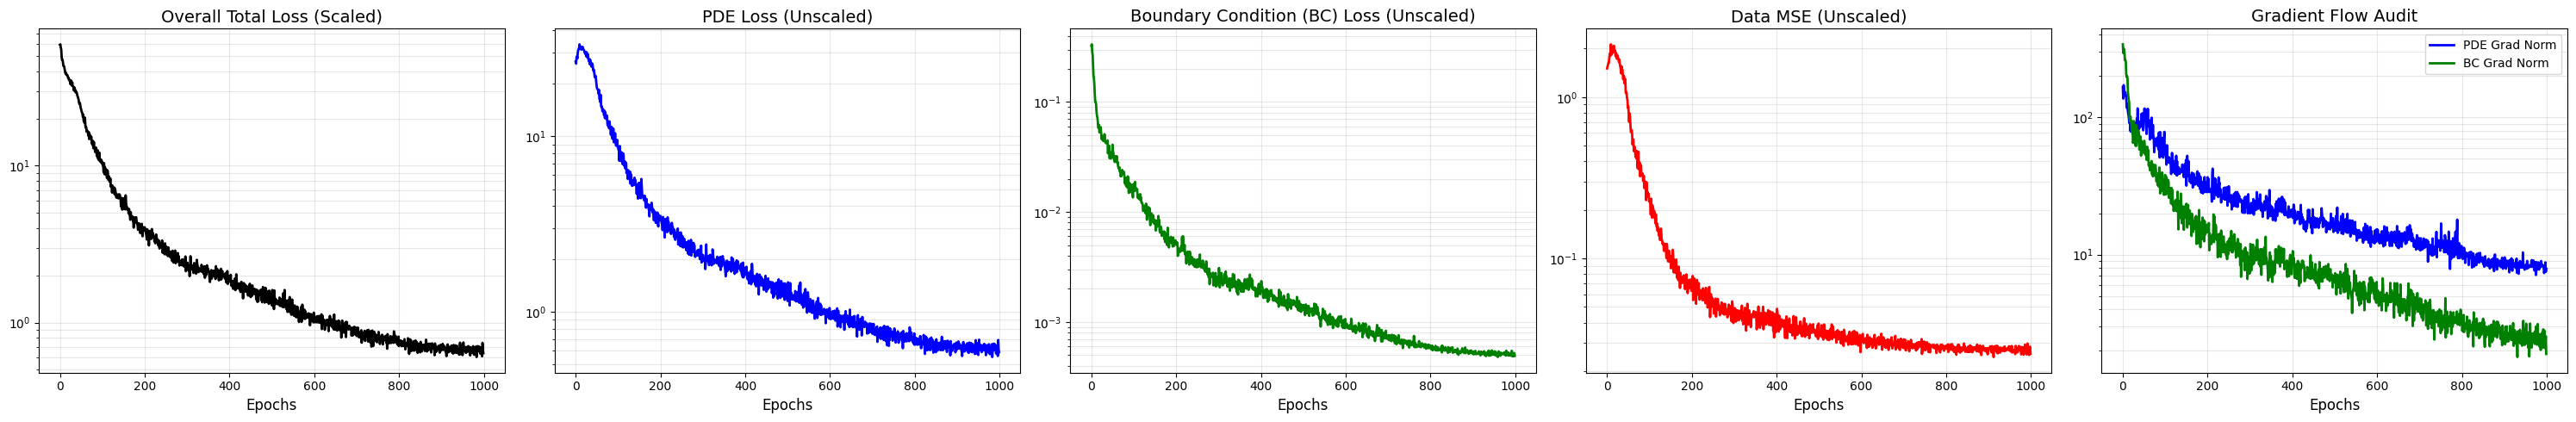

In [10]:
fig, axes = plt.subplots(1, 5, figsize=(30, 5)) 

axes[0].plot(history_total, color='black', linewidth=2)
axes[0].set_title('Overall Total Loss (Scaled)', fontsize=14)

axes[1].plot(history_pde, color='blue', linewidth=2)
axes[1].set_title('PDE Loss (Unscaled)', fontsize=14)

axes[2].plot(history_bc, color='green', linewidth=2)
axes[2].set_title('Boundary Condition (BC) Loss (Unscaled)', fontsize=14)

axes[3].plot(history_data, color='red', linewidth=2)
axes[3].set_title('Data MSE (Unscaled)', fontsize=14)

# --- Gradient Audit Plot ---
axes[4].plot(history_g_pde, color='blue', linewidth=2, label='PDE Grad Norm')
axes[4].plot(history_g_bc, color='green', linewidth=2, label='BC Grad Norm')
axes[4].set_title('Gradient Flow Audit', fontsize=14)
axes[4].legend()

for ax in axes:
    ax.set_yscale('log')
    ax.set_xlabel('Epochs', fontsize=12)
    ax.grid(True, which="both", ls="-", alpha=0.3)

plt.tight_layout()
plt.show()

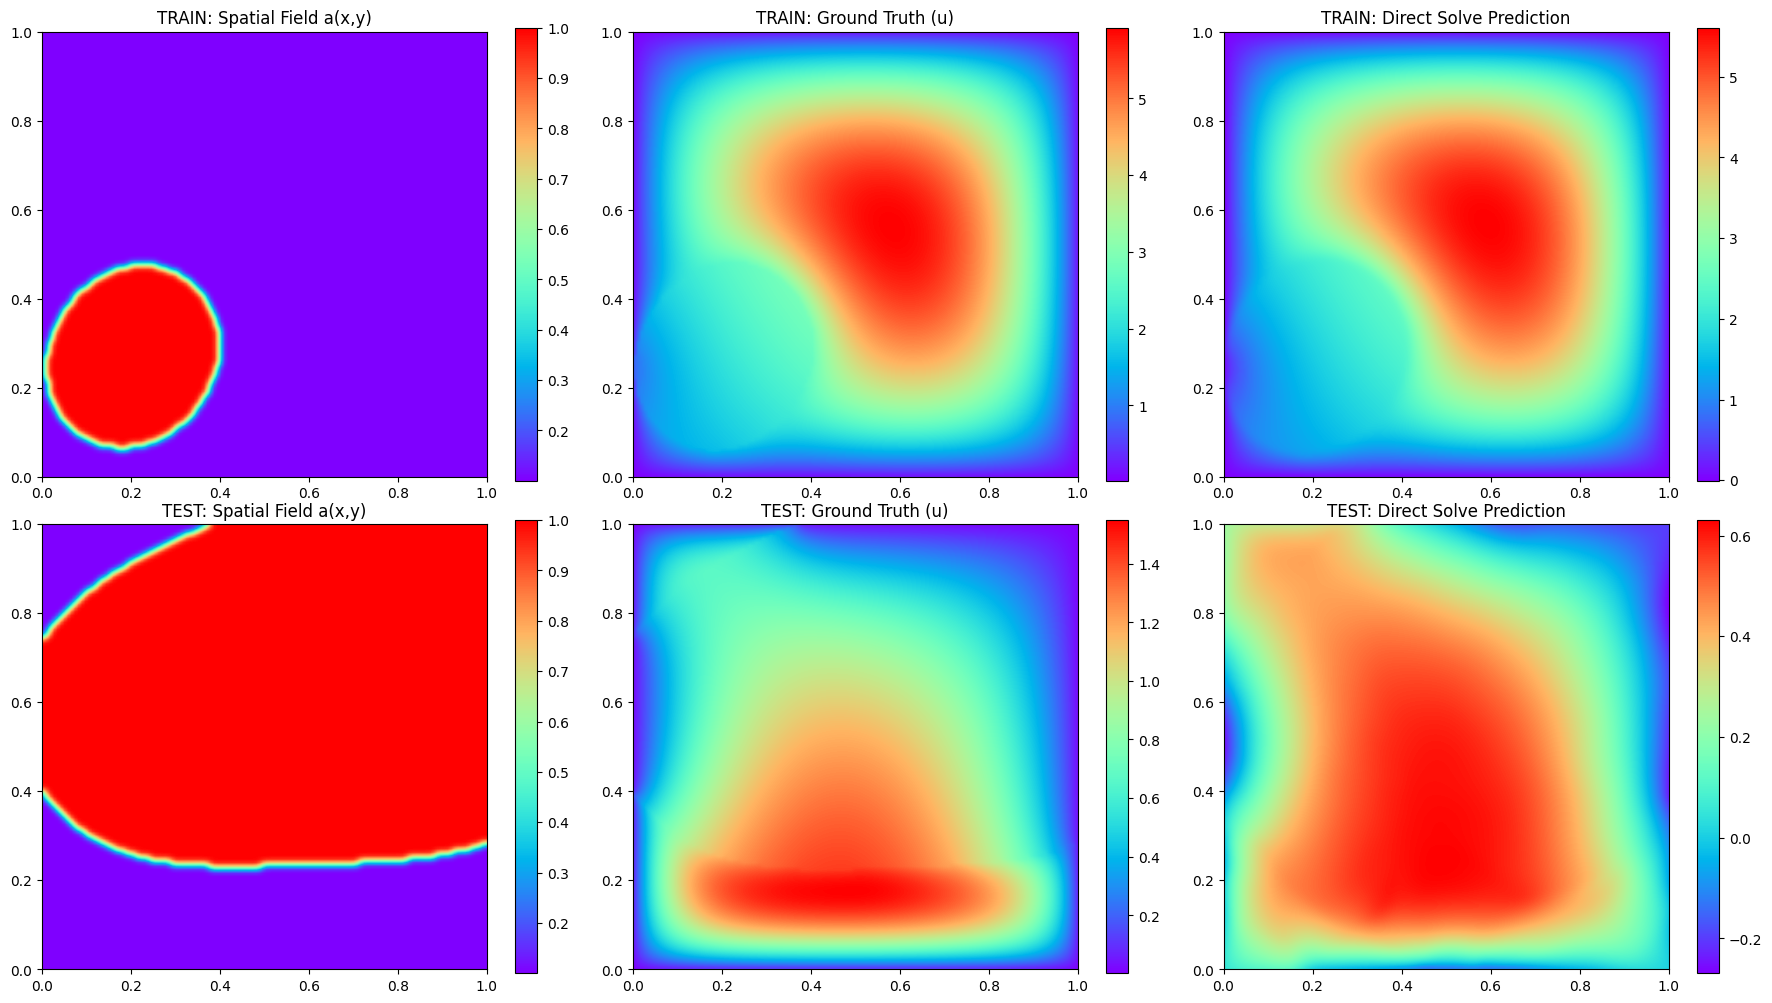

TRAIN Relative L2 Error: 8.4370e-02 (or 8.44%)
TEST  Relative L2 Error: 5.6698e-01 (or 56.70%)


In [15]:
idx_train = 3
idx_test = 0

a_tr, ax_tr, ay_tr, u_sim_tr = train_dataset[idx_train]
a_te, ax_te, ay_te, u_sim_te = test_dataset[idx_test]

a_batch = jnp.stack([a_tr, a_te], axis=0)
a_x_batch = jnp.stack([ax_tr, ax_te], axis=0)
a_y_batch = jnp.stack([ay_tr, ay_te], axis=0)

w_batch = update_direct_solve_batch(
    params, x, y, 
    a_batch, a_x_batch, a_y_batch, 
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

f_eval = f_spatial_vmap(params, x, y)

w_tr = w_batch[0] 
w_te = w_batch[1] 

u_pred_tr = jnp.dot(f_eval, w_tr)
u_pred_te = jnp.dot(f_eval, w_te)

a_plot_tr = a_tr.reshape(fine_nx, fine_ny).T
u_sim_plot_tr = u_sim_tr.reshape(fine_nx, fine_ny).T 
u_pred_plot_tr = u_pred_tr.reshape(fine_nx, fine_ny).T

a_plot_te = a_te.reshape(fine_nx, fine_ny).T
u_sim_plot_te = u_sim_te.reshape(fine_nx, fine_ny).T 
u_pred_plot_te = u_pred_te.reshape(fine_nx, fine_ny).T

ext = [0.0, 1.0, 0.0, 1.0]
fig, axes = plt.subplots(2, 3, figsize=(18, 10))

# --- ROW 1: TRAIN SAMPLE ---
mesh00 = axes[0, 0].imshow(a_plot_tr, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh00, ax=axes[0, 0])
axes[0, 0].set_title(f'TRAIN: Spatial Field a(x,y)')

mesh01 = axes[0, 1].imshow(u_sim_plot_tr, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh01, ax=axes[0, 1])
axes[0, 1].set_title('TRAIN: Ground Truth (u)')

mesh02 = axes[0, 2].imshow(u_pred_plot_tr, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh02, ax=axes[0, 2])
axes[0, 2].set_title('TRAIN: Direct Solve Prediction')

# --- ROW 2: TEST SAMPLE ---
mesh10 = axes[1, 0].imshow(a_plot_te, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1.)
fig.colorbar(mesh10, ax=axes[1, 0])
axes[1, 0].set_title(f'TEST: Spatial Field a(x,y)')

mesh11 = axes[1, 1].imshow(u_sim_plot_te, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh11, ax=axes[1, 1])
axes[1, 1].set_title('TEST: Ground Truth (u)')

mesh12 = axes[1, 2].imshow(u_pred_plot_te, interpolation='bilinear', origin='lower', cmap='rainbow', extent=ext, aspect=1)
fig.colorbar(mesh12, ax=axes[1, 2])
axes[1, 2].set_title('TEST: Direct Solve Prediction')

plt.tight_layout()
plt.show()

# --- Relative L2 Errors ---
err_tr = jnp.linalg.norm(u_pred_tr.flatten() - u_sim_tr.flatten()) / jnp.linalg.norm(u_sim_tr.flatten())
err_te = jnp.linalg.norm(u_pred_te.flatten() - u_sim_te.flatten()) / jnp.linalg.norm(u_sim_te.flatten())

print(f"TRAIN Relative L2 Error: {err_tr:.4e} (or {err_tr * 100:.2f}%)")
print(f"TEST  Relative L2 Error: {err_te:.4e} (or {err_te * 100:.2f}%)")

Starting Diagnostics...


<>:59: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
<>:59: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
/tmp/ipykernel_3360/66057878.py:59: SyntaxWarning: "\P" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\P"? A raw string is also an option.
  ax1.set_title('Singular Values of the MLP Feature Matrix $\Phi$')



--- Test 1: Matrix Health Check ---
Condition Number of (A^T A + lambda I): 2.8416e+05
L2 Norm of predicted weights (w): 3.2086e-01

--- Test 2: SVD of Feature Dictionary ---


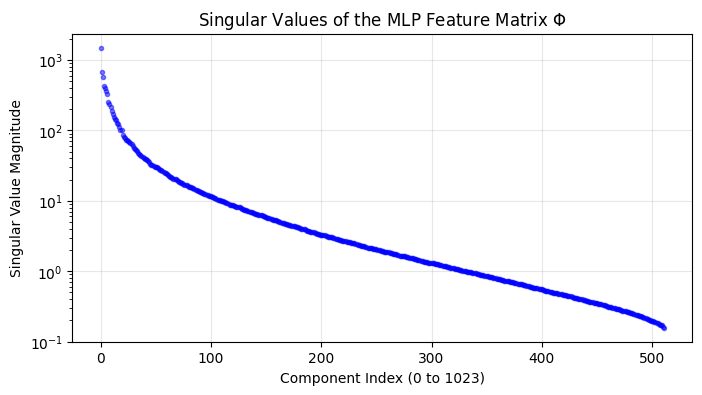


--- Test 3: Visualizing Latent Basis Functions ---


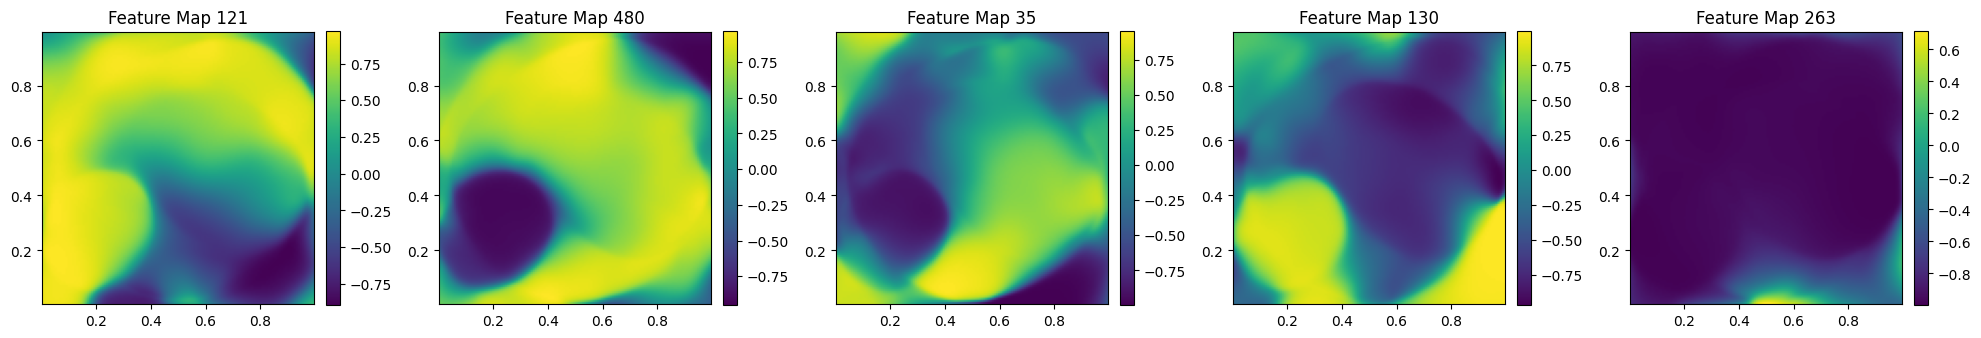


--- Test 4: Spatial Residual Mapping ---


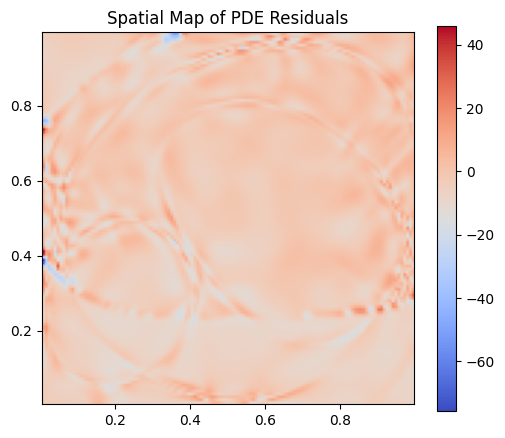

In [12]:
# --- Diagnostics Cell ---
import jax.numpy as jnp
import jax
import matplotlib.pyplot as plt

print("Starting Diagnostics...")

# --- Setup: Grab a single test sample ---
test_idx = 0
a_sample, a_x_sample, a_y_sample, u_sim_sample = test_dataset[test_idx]
a_batch_test = a_sample[None, ...]
a_x_batch_test = a_x_sample[None, ...]
a_y_batch_test = a_y_sample[None, ...]

# We need the grid dimensions for reshaping later
nx, ny = len(fine_x_coords), len(fine_y_coords)
ext = [float(jnp.min(x)), float(jnp.max(x)), float(jnp.min(y)), float(jnp.max(y))]

# ==========================================
# TEST 1: Matrix Health Check
# ==========================================
print("\n--- Test 1: Matrix Health Check ---")
# Assemble the A matrix and target b
A_batch, b_batch = get_A_and_b_optimized(
    params, x, y, 
    a_batch_test, a_x_batch_test, a_y_batch_test, 
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)

A_single = A_batch[0]
AtA = A_single.T @ A_single + tik_reg_fixed * jnp.eye(total_features)

cond_number = jnp.linalg.cond(AtA)
print(f"Condition Number of (A^T A + lambda I): {cond_number:.4e}")

# Solve for w to check magnitude
w_test = update_direct_solve_batch(
    params, x, y, 
    a_batch_test, a_x_batch_test, a_y_batch_test, 
    x_bc, y_bc, bc_val_array, total_features, chunk_size
)
w_norm = jnp.linalg.norm(w_test[0])
print(f"L2 Norm of predicted weights (w): {w_norm:.4e}")


# ==========================================
# TEST 2: SVD of the Feature Dictionary
# ==========================================
print("\n--- Test 2: SVD of Feature Dictionary ---")
# Evaluate the learned basis features over the entire spatial grid
f_eval = f_spatial_vmap(params, x, y)

# SVD to check for feature collapse
s = jnp.linalg.svd(f_eval, compute_uv=False)

fig1, ax1 = plt.subplots(figsize=(8, 4))
ax1.plot(s, marker='.', linestyle='none', color='blue', alpha=0.5)
ax1.set_yscale('log')
ax1.set_title('Singular Values of the MLP Feature Matrix $\Phi$')
ax1.set_xlabel('Component Index (0 to 1023)')
ax1.set_ylabel('Singular Value Magnitude')
ax1.grid(True, alpha=0.3)
plt.show()


# ==========================================
# TEST 3: Visualizing Latent Basis Functions
# ==========================================
print("\n--- Test 3: Visualizing Latent Basis Functions ---")
num_features_to_plot = 5
rng_features = jax.random.PRNGKey(42)
feature_indices = jax.random.choice(rng_features, jnp.arange(total_features), shape=(num_features_to_plot,), replace=False)

fig2, axes2 = plt.subplots(1, num_features_to_plot, figsize=(4 * num_features_to_plot, 4))

for i, f_idx in enumerate(feature_indices):
    feat_map = f_eval[:, f_idx].reshape(nx, ny).T
    im = axes2[i].imshow(feat_map, origin='lower', cmap='viridis', extent=ext)
    axes2[i].set_title(f"Feature Map {f_idx}")
    fig2.colorbar(im, ax=axes2[i], fraction=0.046, pad=0.04)

plt.tight_layout()
plt.show()


# ==========================================
# TEST 4: Spatial Residual Mapping
# ==========================================
print("\n--- Test 4: Spatial Residual Mapping ---")
# Get derivatives of the prediction using the solved w
u_x, u_y, u_xx, u_yy = u_dir_spatial_vmap(params, x, y, w_test[0])
laplacian_u = u_xx + u_yy

# Strip batch dim for the exact fields
a_field = a_batch_test[0]
ax_field = a_x_batch_test[0]
ay_field = a_y_batch_test[0]

# Calculate the exact PDE residual point-by-point
pde_residual = -(ax_field * u_x + ay_field * u_y + a_field * laplacian_u) - beta
pde_residual_2d = pde_residual.reshape(nx, ny).T

fig3, ax3 = plt.subplots(figsize=(6, 5))
im3 = ax3.imshow(pde_residual_2d, origin='lower', cmap='coolwarm', extent=ext)
ax3.set_title('Spatial Map of PDE Residuals')
fig3.colorbar(im3, ax=ax3)
plt.show()